In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors

import scanpy as sc
import squidpy as sq
import cellcharter as cc
import scvi

from pandas.api.types import is_numeric_dtype, is_categorical_dtype
from scipy.sparse import issparse

import sys
sys.path.append("/Users/christoffer/work/karolinska/development/MANA")
from utils import aggregate_neighbors_weighted, plot_spatial_compact_fast



# adding raw data to object

In [2]:
ad_raw = sc.read_h5ad('../../data/talbot_xenium.h5ad')
ad_raw = ad_raw[ad_raw.obs.tissue == 'tumor']
ad_raw

sc.pp.calculate_qc_metrics(ad_raw, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(ad_raw,min_counts=30)
sc.pp.filter_cells(ad_raw,min_genes=10)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [4]:
import h5py
h5ad_path = '/Users/christoffer/work/spatialist/talbot_xenium/data/talbot_xenium_tumor_annotated-with-hvg.h5ad'
with h5py.File(h5ad_path, 'a') as f:
    if 'uns' in f and 'cytetype_jobDetails' in f['uns']:
        grp = f['uns/cytetype_jobDetails']
        if 'auth_token' in grp:
            del grp['auth_token']
        # If empty after cleanup, drop the group to keep uns tidy
        if len(grp.keys()) == 0:
            del f['uns/cytetype_jobDetails']


In [5]:
ad = sc.read_h5ad('/Users/christoffer/work/spatialist/talbot_xenium/data/talbot_xenium_tumor_annotated-with-hvg.h5ad')
ad.obs.sample_id.str = ad.obs.sample_id.str.split('73__', expand=True)[1]

In [6]:
ad.layers['counts'] = ad_raw.X.copy()
ad.layers['normalized'] = ad.X.copy()

In [7]:
ad_sub = ad.copy()

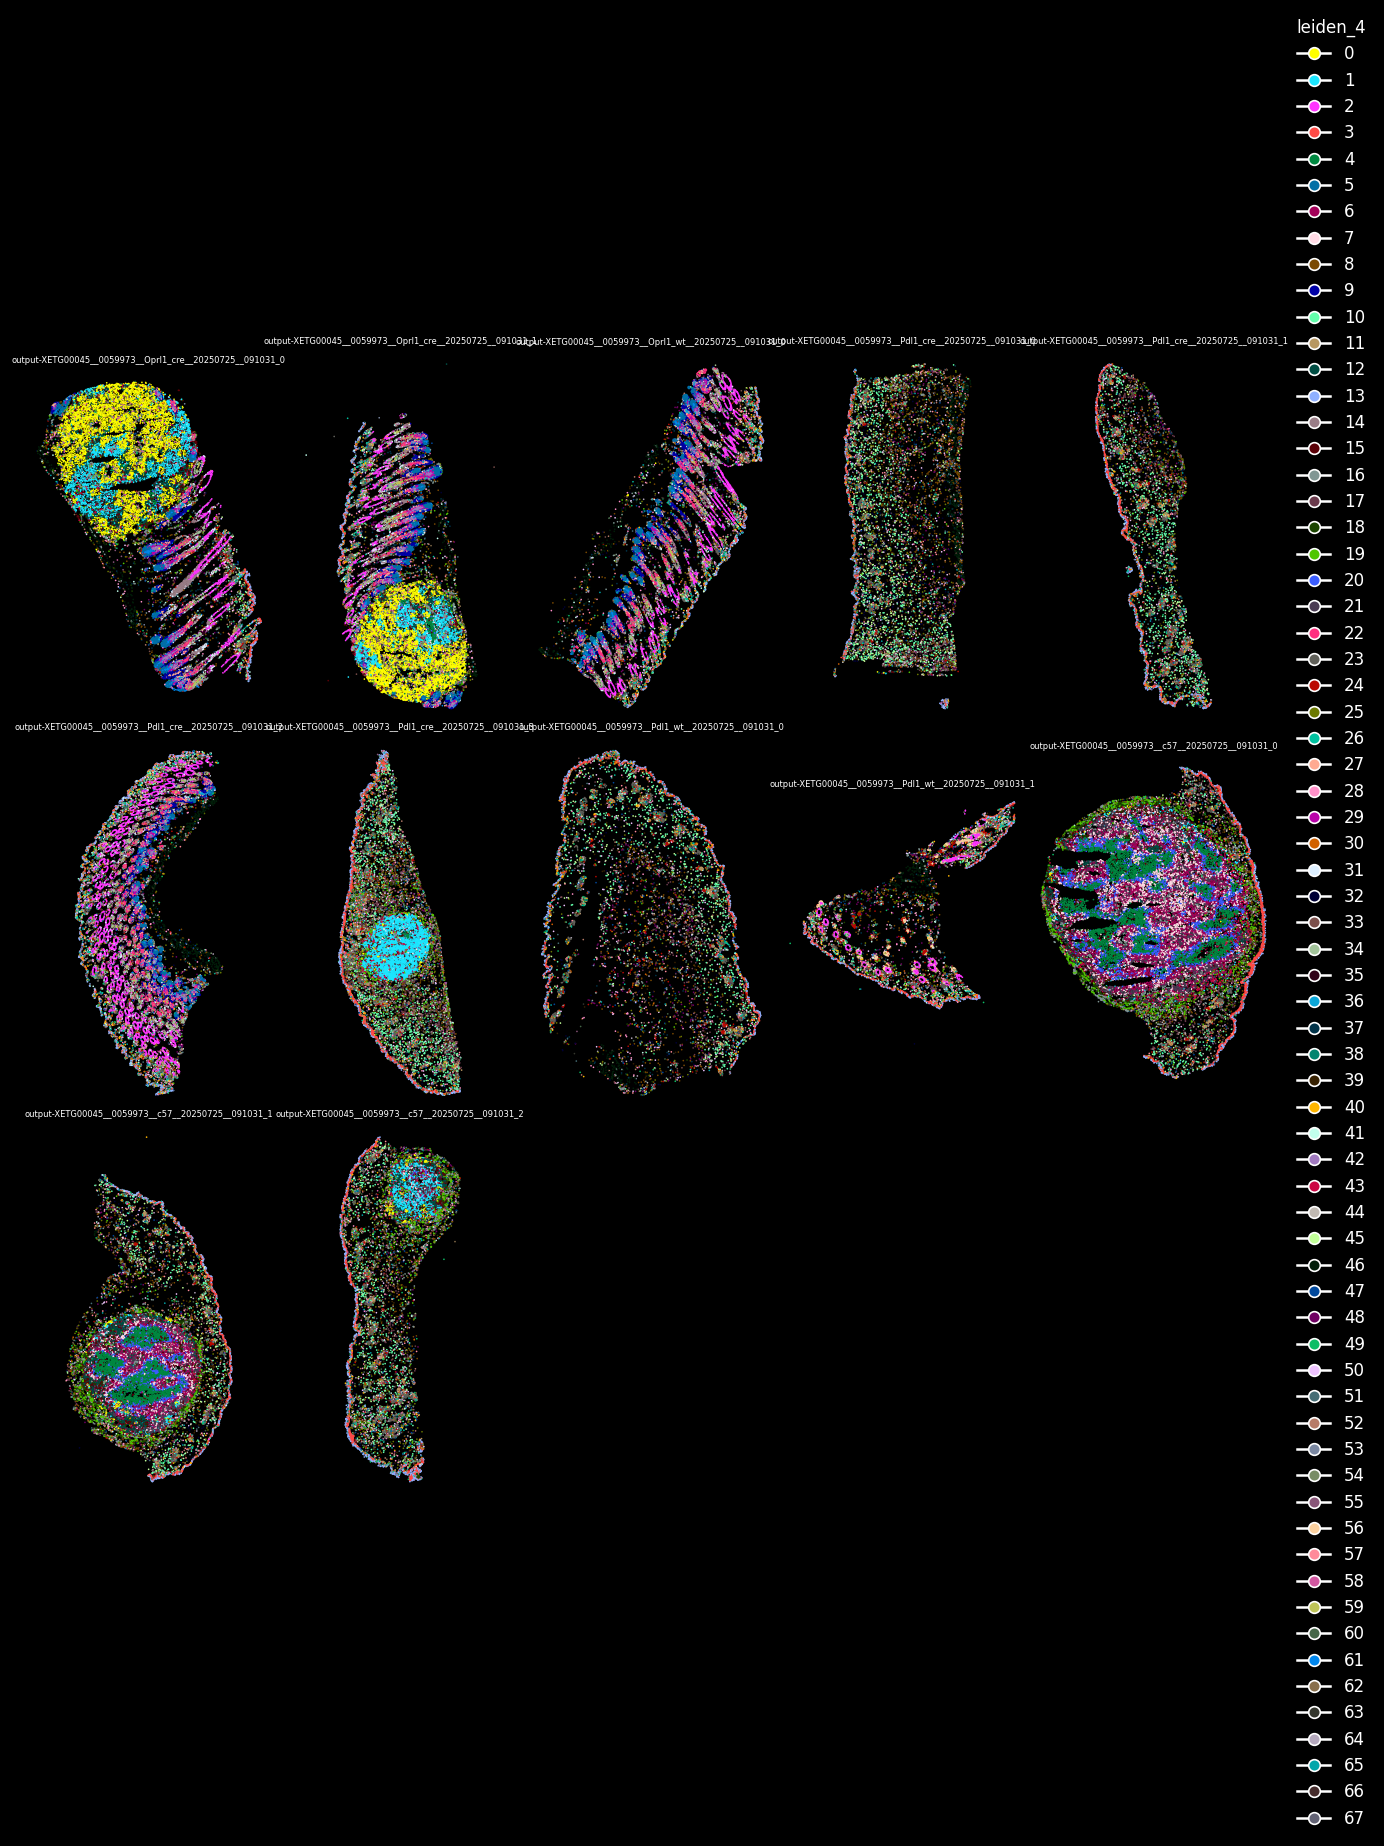

In [8]:
# usage
plot_spatial_compact_fast(
    ad_sub,
    color="leiden_4",
    groupby="sample_id",
    spot_size=1,
    cols=5,
    height=10,
    legend_col_width=1.0,
    background="black",
    grey_alpha=0.05,
    #highlight=['4','5']
)

In [9]:
# Ensure all layers are sparse CSR matrices
from scipy.sparse import csr_matrix, issparse

for name, layer in list(ad_sub.layers.items()):
    if not issparse(layer):
        ad_sub.layers[name] = csr_matrix(layer)

# Optional: verify
{k: type(v).__name__ for k, v in ad_sub.layers.items()}


{'counts': 'csr_matrix', 'normalized': 'csr_matrix'}

In [10]:

sc.pp.highly_variable_genes(
    ad_sub,
    n_top_genes=500,     # try 1500–2000
    flavor="seurat_v3"
)

In [11]:
ad_sub = ad_sub[:, ad_sub.var["highly_variable"]].copy()

In [12]:
ad_sub

AnnData object with n_obs × n_vars = 207468 × 500
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4', 'cytetype_annotation_leiden_4', 'cytetype_cellOntologyTerm_leiden_4'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'cytetype_annotation_leiden_4_colors', 'cytetype_jobDetails', 'cytetype_results', 'genotype_colors', 'hvg',

In [13]:
scvi.model.SCVI.setup_anndata(
    ad_sub, 
    layer="counts", 
    batch_key='sample_id',
)

model = scvi.model.SCVI(ad_sub)

In [14]:
model.train(early_stopping=True, max_epochs = 30, enable_progress_bar=True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Epoch 30/30: 100%|██████████| 30/30 [07:09<00:00, 13.91s/it, v_num=1, train_loss_step=47.5, train_loss_epoch=50.8]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 30/30: 100%|██████████| 30/30 [07:09<00:00, 14.33s/it, v_num=1, train_loss_step=47.5, train_loss_epoch=50.8]


In [15]:
ad_sub

AnnData object with n_obs × n_vars = 207468 × 500
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4', 'cytetype_annotation_leiden_4', 'cytetype_cellOntologyTerm_leiden_4', '_scvi_batch', '_scvi_labels'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'gene_symbols', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'cytetype_annotation_leiden_4_colors', 'cytetype_jobDetails', 'cytetype_resu

In [16]:
# Get scVI latent representation
ad_sub.obsm['X_scVI'] = model.get_latent_representation()

print(f"Added X_scVI to ad_sub.obsm with shape: {ad_sub.obsm['X_scVI'].shape}")

Added X_scVI to ad_sub.obsm with shape: (207468, 10)


In [17]:
import squidpy as sq

# Build spatial graph
# This should be done per-sample to avoid creating edges between samples
sq.gr.spatial_neighbors(
    ad_sub,
    coord_type='generic',
    delaunay=True,  # Delaunay triangulation (connects nearby cells)
    key_added='spatial',
    library_key='sample_id'  # Ensure no edges between different samples,
)

print(f"Spatial graph built: {ad_sub.obsp['spatial_connectivities'].shape}")
print(f"Average neighbors per cell: {ad_sub.obsp['spatial_connectivities'].sum(axis=1).mean():.1f}")

Spatial graph built: (207468, 207468)
Average neighbors per cell: 6.0


In [18]:
import cellcharter as cc

In [19]:
cc.gr.remove_long_links(ad_sub)

In [20]:
# Run MANA with memory-efficient per-sample processing
# Adjust 'sample_key' to match your actual sample column name!

aggregate_neighbors_weighted(
    ad_sub,
    n_layers=3,              # Optimal balance (from MANA-5)
    aggregations='mean',     # Standard aggregation
    use_rep='X_scVI',        # Use scVI latent space
    out_key='X_mana_gauss',  # Output key
    hop_decay=0.2,           # Optimal decay (from MANA-4)
    distance_kernel='gaussian',  # Winner from MANA-6 benchmark
    spatial_key='spatial',
    normalize_weights=True,
    include_self=True,
    sample_key='sample_id',  # CRITICAL: Process per-sample to avoid memory issues!
)

print("\nMANA aggregation complete!")
print(f"Output stored in adata.obsm['X_mana_gauss'] with shape: {ad_sub.obsm['X_mana_gauss'].shape}")

Processing 12 samples separately for memory efficiency...
  Processing sample 1/12: output-XETG00045__0059973__Pdl1_wt__20250725__091031_1 (6,305 cells)
  Processing sample 2/12: output-XETG00045__0059973__Pdl1_wt__20250725__091031_0 (8,983 cells)
  Processing sample 3/12: output-XETG00045__0059973__Oprl1_cre__20250725__091031_1 (24,636 cells)
  Processing sample 4/12: output-XETG00045__0059973__Oprl1_cre__20250725__091031_0 (20,675 cells)
  Processing sample 5/12: output-XETG00045__0059973__c57__20250725__091031_2 (13,693 cells)
  Processing sample 6/12: output-XETG00045__0059973__c57__20250725__091031_1 (20,679 cells)
  Processing sample 7/12: output-XETG00045__0059973__c57__20250725__091031_0 (28,219 cells)
  Processing sample 8/12: output-XETG00045__0059973__Oprl1_wt__20250725__091031_0 (19,893 cells)
  Processing sample 9/12: output-XETG00045__0059973__Pdl1_cre__20250725__091031_1 (7,120 cells)
  Processing sample 10/12: output-XETG00045__0059973__Pdl1_cre__20250725__091031_3 (19,

In [21]:
# Build neighborhood graph in MANA feature space
sc.pp.neighbors(
    ad_sub,
    use_rep='X_mana_gauss',
    n_neighbors=15,
    key_added='mana'
)

print("Neighbor graph built in MANA feature space")

Neighbor graph built in MANA feature space


In [ ]:
# Leiden clustering
# Try a few resolutions to see what works best
resolutions = [0.3, 0.5, 0.8, 1.0, 1.5,2]

for res in resolutions:
    sc.tl.leiden(
        ad_sub,
        resolution=res,
        key_added=f'leiden_mana_{res}',
        neighbors_key='mana'
    )
    n_clusters = ad_sub.obs[f'leiden_mana_{res}'].nunique()
    print(f"Resolution {res}: {n_clusters} clusters")

Resolution 0.3: 8 clusters
Resolution 0.5: 12 clusters
Resolution 0.8: 18 clusters
Resolution 1.0: 22 clusters


In [ ]:
# Visualize MANA clustering (resolution 0.5 as starting point)
plot_spatial_compact_fast(
    ad_sub, 
    color='leiden_mana_2',
    groupby='sample_id',  # Adjust to your actual sample column
    spot_size = 1,
    cols=8,
    height=20,
    background='white',
    dpi=120,
   
)

In [ ]:

# Save MANA-processed object for downstream use
# (Note: this is Talbot xenium melanoma data — previously written to a path
#  from a different project. Now saving to the correct project location.)
out_path = '../../data/talbot_xenium_tumor_mana.h5ad'
ad_sub.write(out_path)
print(f"Saved to {out_path}")